In [1]:
#Package Import
import pandas as pd
import re
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Slicing Function
def process_news(title, full_text, max_words=2250):
    
    """Combines news title and article body into a structured, unified string 
    optimized for GPT-4o Mini, capping the body safely at 2250 words."""
    
    #Clean and normalize inputs safely
    title_str = str(title).strip() if pd.notna(title) else ""
    text_str = str(full_text).strip() if pd.notna(full_text) else ""
    
    #Text normalization: Strip web clutter while preserving casing/punctuation
    text_str = re.sub(r'https?://\S+|www\.\S+', '', text_str)
    text_str = re.sub(r'<.*?>', '', text_str)
    text_str = re.sub(r'\s+', ' ', text_str)
    
    #Tokenize by space to measure absolute word lengths
    words = text_str.split(' ')
    
    #Removes empty string artifacts caused by split handling
    words = [w for w in words if w]
    
    #Global Window Selection: Captures up to the absolute 2250 word limit
    #If the text is short (e.g., 200 words), words[:max_words] safely returns all 200 words without error.
    context_words = words[:max_words]
    body_payload = ' '.join(context_words)
    
    #Building high-density structural text input template
    if title_str:
        final_input = f"TITLE: {title_str}\n\nBODY: {body_payload}"
    else:
        final_input = f"BODY: {body_payload}"
        
    return final_input.strip()

In [3]:
#PreProcessing
def preprocessing_pipeline(df, ticker_col='Stock_symbol', headline_col='Article_title', text_col='Article'):
    df['gpt_input'] = df.apply(
        lambda row: process_news(
            title=row[headline_col],
            full_text=row[text_col],
            max_words=2250
        ), axis=1
    )

In [4]:
#Datasets - Cleaned News Data
dataset_A = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\News_Dataset A.csv")
dataset_B = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\News_Dataset B.csv")

In [5]:
#Dataset A Execution
preprocessing_pipeline(dataset_A)

In [6]:
#Dataset B Execution
preprocessing_pipeline(dataset_B)

In [8]:
#Adding Processed word counts
dataset_A['gpt_input_len'] = dataset_A['gpt_input'].apply(lambda x:len(x.split()))
dataset_B['gpt_input_len'] = dataset_B['gpt_input'].apply(lambda x:len(x.split()))

In [9]:
dataset_A.head(2)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,gpt_input,gpt_input_len
0,2023-12-16,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate...",2023,2968,TITLE: ADSK Quantitative Stock Analysis\n\nBOD...,461
1,2023-12-16,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,2023,9366,TITLE: Artificial Intelligence Adding New Dept...,1442


In [10]:
dataset_B.head(2)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,relevance_score,Relevance_Tier,Month,gpt_input,gpt_input_len
0,2019-01-02,The Fire Within Netflix Stock Still Burns Desp...,CMCSA,"InvestorPlace - Stock Market News, Stock Advic...",The result is many analysts are now piling int...,The result is many analysts are now piling int...,2019,5001,4,Low Impact (2-4),1,TITLE: The Fire Within Netflix Stock Still Bur...,869
1,2019-01-02,Don’t Let the Class-Action Suit Dissuade You f...,INTC,"InvestorPlace - Stock Market News, Stock Advic...",7 Stocks to Sell In January Another top compet...,7 Stocks to Sell In January Another top compet...,2019,6003,4,Low Impact (2-4),1,TITLE: Don’t Let the Class-Action Suit Dissuad...,952


In [11]:
#Counts Statistics - Dataset A
display(dataset_A['gpt_input_len'].describe().loc[['min', 'mean', 'max']])

min        6.000000
mean     645.739389
max     2272.000000
Name: gpt_input_len, dtype: float64

In [13]:
#Counts Statistics - Dataset B
display(dataset_B['gpt_input_len'].describe().loc[['min', 'mean', 'max']])

min        8.000000
mean     698.768725
max     2272.000000
Name: gpt_input_len, dtype: float64

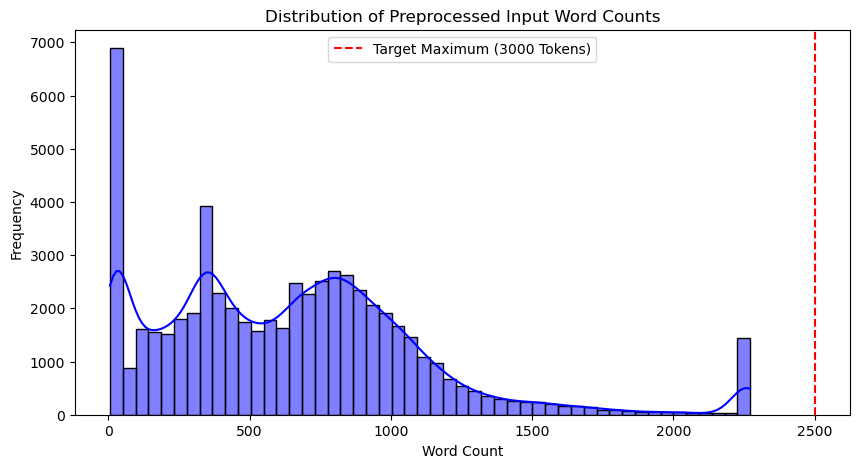

In [14]:
#Word count distribution
#Plot - Dataset A
plt.figure(figsize=(10, 5))
sns.histplot(dataset_A['gpt_input_len'], bins=50, kde=True, color='blue')
plt.axvline(x=2500, color='red', linestyle='--', label='Target Maximum (3000 Tokens)')
plt.title('Distribution of Preprocessed Input Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('gpt_newsA_input_distribution.png', dpi=300)
plt.show()

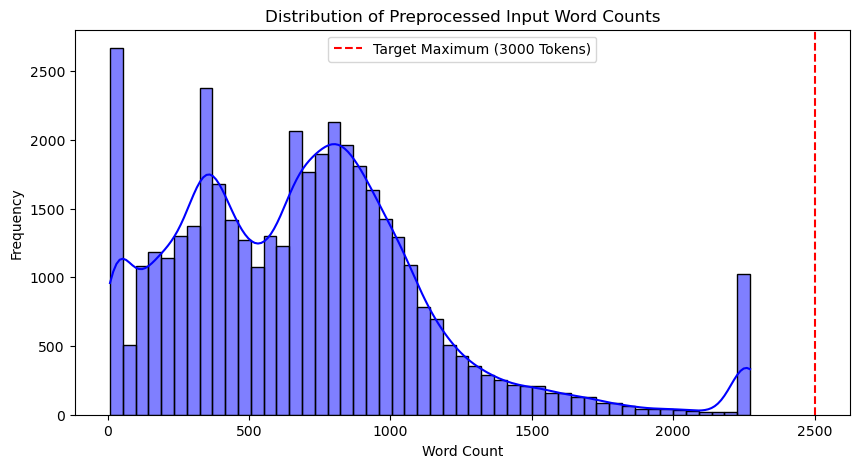

In [15]:
#Word count distribution
#Plot - Dataset B
plt.figure(figsize=(10, 5))
sns.histplot(dataset_B['gpt_input_len'], bins=50, kde=True, color='blue')
plt.axvline(x=2500, color='red', linestyle='--', label='Target Maximum (3000 Tokens)')
plt.title('Distribution of Preprocessed Input Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('gpt_newsB_input_distribution.png', dpi=300)
plt.show()